In [1]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, confusion_matrix,
    matthews_corrcoef, roc_auc_score, f1_score
)
from xgboost import XGBClassifier
import shap
import os

os.makedirs('../models', exist_ok=True)
os.makedirs('../figures', exist_ok=True)

In [2]:
X_train = joblib.load('../data/processed/X_train.pkl')
X_test  = joblib.load('../data/processed/X_test.pkl')
y_train = joblib.load('../data/processed/y_train.pkl')
y_test  = joblib.load('../data/processed/y_test.pkl')
le      = joblib.load('../models/label_encoder.pkl')
feat_names = joblib.load('../models/feature_names.pkl')

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"Classes: {list(le.classes_)}")
print("✅ Data loaded. Ready to train.")

X_train: (348142, 25)
X_test:  (503881, 25)
Classes: ['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'Heartbleed', 'Infiltration', 'PortScan', 'SSH-Patator', 'Web Attack � Brute Force', 'Web Attack � Sql Injection', 'Web Attack � XSS']
✅ Data loaded. Ready to train.


In [3]:
print("Training Random Forest... (2-5 mins)")

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
rf.fit(X_train, y_train)
joblib.dump(rf, '../models/random_forest.pkl')
print("✅ Saved: models/random_forest.pkl")

Training Random Forest... (2-5 mins)


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    2.8s


✅ Saved: models/random_forest.pkl


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    8.5s finished


In [4]:
print("Training XGBoost... (3-8 mins)")

xgb = XGBClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    verbosity=1,
    use_label_encoder=False,
    eval_metric='mlogloss'
)
xgb.fit(X_train, y_train)
joblib.dump(xgb, '../models/xgb_model.pkl')
print("✅ Saved: models/xgb_model.pkl")

Training XGBoost... (3-8 mins)
✅ Saved: models/xgb_model.pkl


In [5]:
from sklearn.utils import resample

print("Training SVM on 100k stratified sample... (5-15 mins)")

# Stratified sample to keep class proportions
X_svm_sample, y_svm_sample = resample(
    X_train, y_train,
    n_samples=100000,
    random_state=42,
    stratify=y_train
)

svm = SVC(kernel='rbf', probability=True, random_state=42)
svm.fit(X_svm_sample, y_svm_sample)
joblib.dump(svm, '../models/svm_model.pkl')
print("✅ Saved: models/svm_model.pkl")

Training SVM on 100k stratified sample... (5-15 mins)
✅ Saved: models/svm_model.pkl


In [6]:
def evaluate_model(model, name, X_test, y_test, le):
    preds = model.predict(X_test)
    
    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    
    print(classification_report(y_test, preds, target_names=le.classes_))
    
    mcc = matthews_corrcoef(y_test, preds)
    f1_w = f1_score(y_test, preds, average='weighted')
    print(f"Weighted F1:  {f1_w:.4f}")
    print(f"MCC:          {mcc:.4f}")
    
    return preds, f1_w, mcc

rf_preds,  rf_f1,  rf_mcc  = evaluate_model(rf,  "RANDOM FOREST", X_test, y_test, le)
xgb_preds, xgb_f1, xgb_mcc = evaluate_model(xgb, "XGBOOST",       X_test, y_test, le)
svm_preds, svm_f1, svm_mcc = evaluate_model(svm, "SVM",           X_test, y_test, le)

[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.5s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    1.6s finished



  RANDOM FOREST
                            precision    recall  f1-score   support

                    BENIGN       1.00      1.00      1.00    418872
                       Bot       0.65      0.98      0.78       390
                      DDoS       1.00      1.00      1.00     25602
             DoS GoldenEye       0.98      1.00      0.99      2057
                  DoS Hulk       0.99      1.00      0.99     34544
          DoS Slowhttptest       0.98      0.99      0.99      1046
             DoS slowloris       0.99      1.00      0.99      1077
               FTP-Patator       1.00      1.00      1.00      1186
                Heartbleed       1.00      1.00      1.00         2
              Infiltration       0.75      0.86      0.80         7
                  PortScan       0.99      1.00      1.00     18026
               SSH-Patator       0.97      1.00      0.98       644
  Web Attack � Brute Force       0.47      0.58      0.52       294
Web Attack � Sql Injection    

In [7]:
comparison = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost', 'SVM'],
    'Weighted F1': [rf_f1, xgb_f1, svm_f1],
    'MCC': [rf_mcc, xgb_mcc, svm_mcc]
})
comparison = comparison.sort_values('Weighted F1', ascending=False)
print("\nMODEL COMPARISON")
print(comparison.to_string(index=False))

# Save to CSV for report
comparison.to_csv('../data/processed/model_comparison.csv', index=False)
print("Saved: data/processed/model_comparison.csv")


MODEL COMPARISON
        Model  Weighted F1      MCC
Random Forest     0.997732 0.991846
      XGBoost     0.967649 0.879230
          SVM     0.907056 0.740916
Saved: data/processed/model_comparison.csv


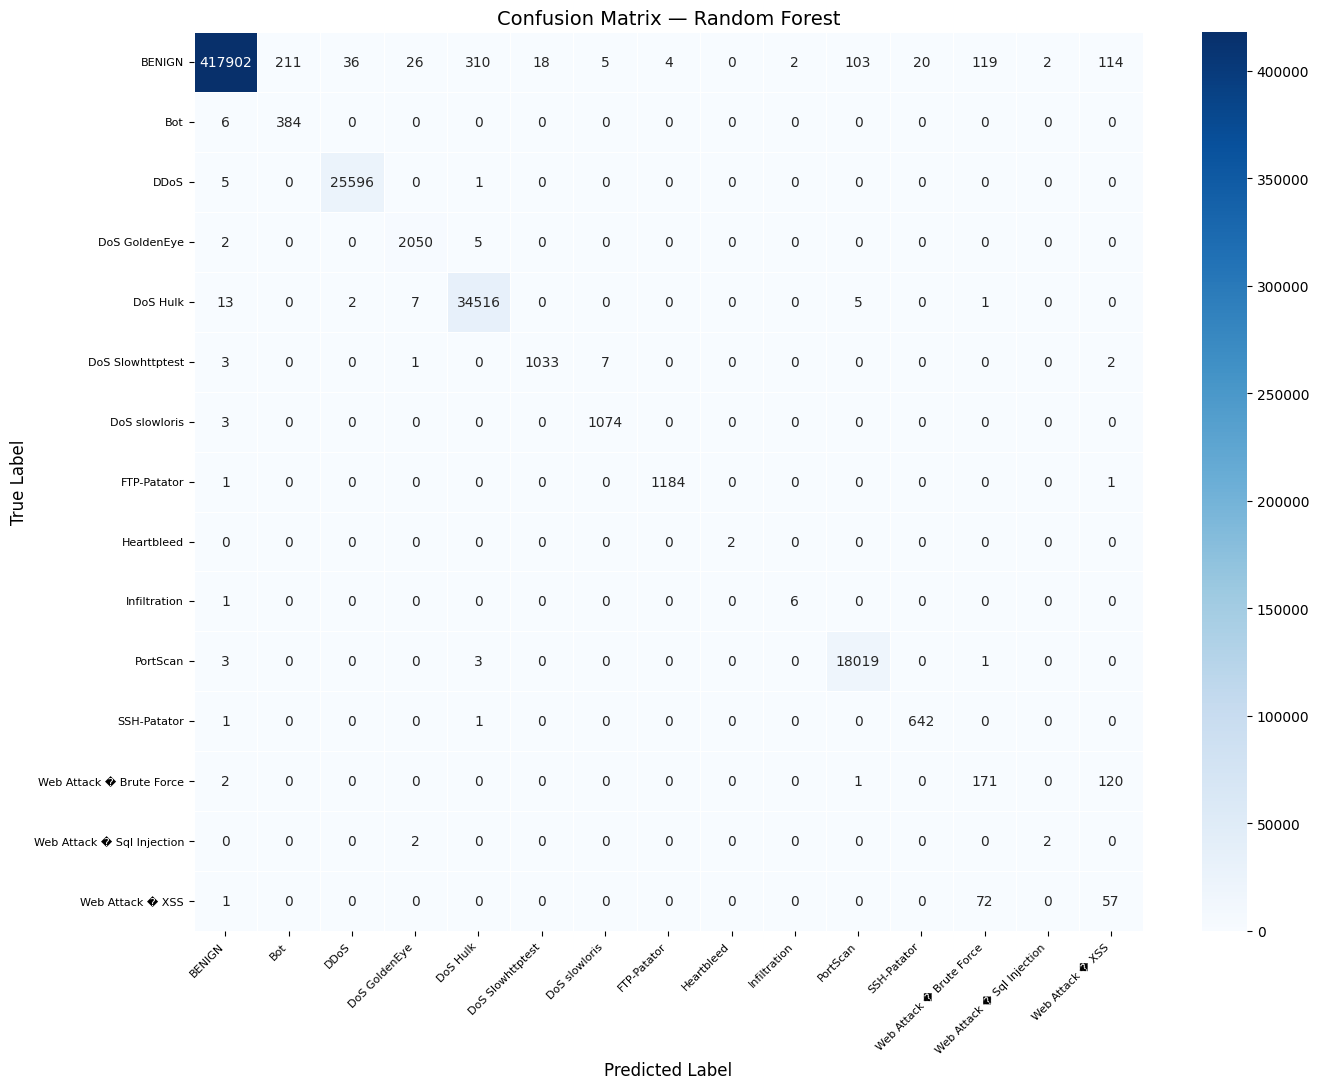

Saved: figures/confusion_matrix_rf.png


In [8]:
cm = confusion_matrix(y_test, rf_preds)

plt.figure(figsize=(14, 11))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    linewidths=0.5
)
plt.title('Confusion Matrix — Random Forest', fontsize=14)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('../figures/confusion_matrix_rf.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/confusion_matrix_rf.png")

In [16]:
print("Computing SHAP values on 500 test samples...")

# X_test already has top 25 features — this is correct
X_shap_sample = X_test[:500]

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_shap_sample)

joblib.dump(explainer,   '../models/shap_explainer.pkl')
joblib.dump(shap_values, '../models/shap_values.pkl')
joblib.dump(shap_values, '../models/shap_values.pkl')  # full (500, 25, 15) array
print(f"Full shap_values shape: {shap_values.shape}")
print("Use shap_values[:, :, class_idx] to extract per-class values")

print(f"✅ Saved explainer and shap_values")
print(f"X_shap_sample shape:   {X_shap_sample.shape}")
print(f"shap_values length:    {len(shap_values)} classes")
print(f"shap_values[0] shape:  {shap_values[0].shape}") 

Computing SHAP values on 500 test samples...
Full shap_values shape: (500, 25, 15)
Use shap_values[:, :, class_idx] to extract per-class values
✅ Saved explainer and shap_values
X_shap_sample shape:   (500, 25)
shap_values length:    500 classes
shap_values[0] shape:  (25, 15)


In [13]:
print(f"X_shap_sample shape:       {X_shap_sample.shape}")
print(f"X_shap_df shape:           {X_shap_df.shape}")
print(f"shap_values type:          {type(shap_values)}")
print(f"shap_values length:        {len(shap_values)}")
print(f"shap_values[0] shape:      {shap_values[0].shape}")
print(f"shap_values[ddos_idx] shape: {shap_values[ddos_idx].shape}")
print(f"feat_names length:         {len(feat_names)}")
print(f"ddos_idx:                  {ddos_idx}")

X_shap_sample shape:       (500, 25)
X_shap_df shape:           (500, 25)
shap_values type:          <class 'numpy.ndarray'>
shap_values length:        500
shap_values[0] shape:      (25, 15)
shap_values[ddos_idx] shape: (25, 15)
feat_names length:         25
ddos_idx:                  2


Extracted DDoS SHAP values shape: (500, 25)


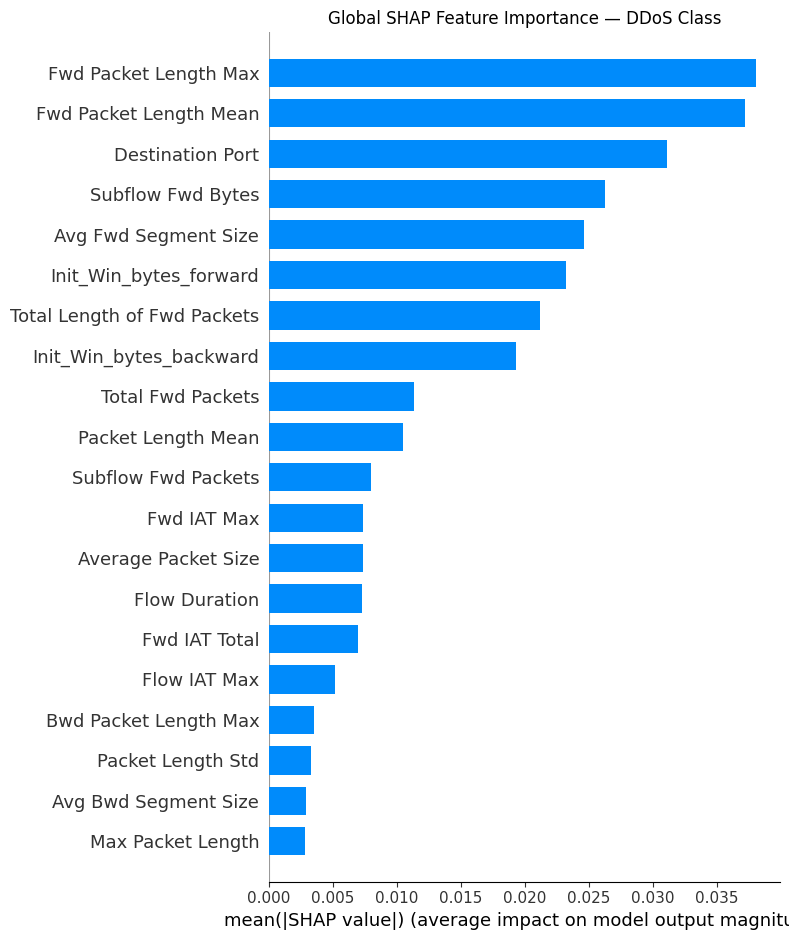

Saved: figures/shap_global_ddos.png


In [17]:
# shap_values shape is (500, 25, 15) — classes are in axis 2
# Extract DDoS class: shap_values[:, :, ddos_idx] gives (500, 25)
shap_vals_ddos = shap_values[:, :, ddos_idx]

print(f"Extracted DDoS SHAP values shape: {shap_vals_ddos.shape}")  # should be (500, 25)

shap.summary_plot(
    shap_vals_ddos,
    X_shap_df,
    plot_type='bar',
    show=False
)
plt.title('Global SHAP Feature Importance — DDoS Class')
plt.tight_layout()
plt.savefig('../figures/shap_global_ddos.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/shap_global_ddos.png")

True label: DDoS
Predicted:  DDoS


[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.0s finished


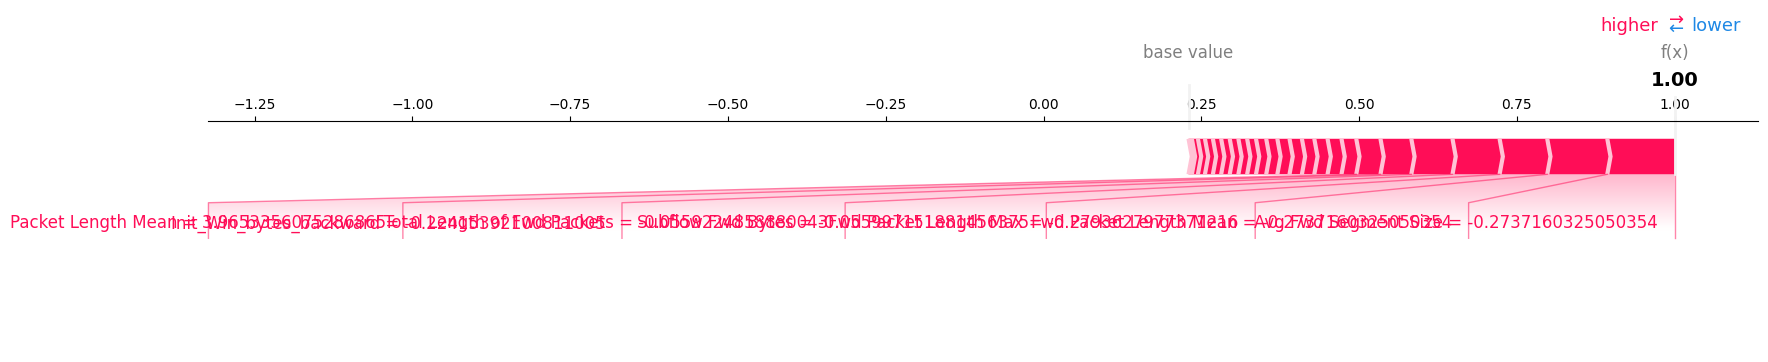

Saved: figures/shap_local_ddos.png


In [18]:
ddos_sample_idx = np.where(y_test[:500] == ddos_idx)[0][0]

print(f"True label: {le.classes_[y_test[ddos_sample_idx]]}")
print(f"Predicted:  {le.classes_[rf.predict(X_shap_sample[ddos_sample_idx:ddos_sample_idx+1])[0]]}")

# expected_value is also per class now
expected_val = explainer.expected_value[ddos_idx]

shap.force_plot(
    expected_val,
    shap_vals_ddos[ddos_sample_idx],       # shape (25,) — one sample, DDoS class
    X_shap_df.iloc[ddos_sample_idx],
    matplotlib=True,
    show=False
)
plt.savefig('../figures/shap_local_ddos.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/shap_local_ddos.png")

In [19]:
print("="*50)
print("PHASE 3 COMPLETE — FINAL VERIFICATION")
print("="*50)

import os
required = [
    '../models/random_forest.pkl',
    '../models/xgb_model.pkl',
    '../models/svm_model.pkl',
    '../models/shap_explainer.pkl',
    '../models/shap_values.pkl',
    '../data/processed/model_comparison.csv',
]
for f in required:
    exists = os.path.exists(f)
    print(f"  {'✅' if exists else '❌'} {f}")

print("\nFigures generated:")
for f in os.listdir('../figures'):
    print(f"  📊 {f}")

print("\n✅ Phase 3 done. Ready to build app.py")

PHASE 3 COMPLETE — FINAL VERIFICATION
  ✅ ../models/random_forest.pkl
  ✅ ../models/xgb_model.pkl
  ✅ ../models/svm_model.pkl
  ✅ ../models/shap_explainer.pkl
  ✅ ../models/shap_values.pkl
  ✅ ../data/processed/model_comparison.csv

Figures generated:
  📊 class_distribution.png
  📊 confusion_matrix_rf.png
  📊 feature_importance.png
  📊 shap_global_ddos.png
  📊 shap_local_ddos.png

✅ Phase 3 done. Ready to build app.py


In [20]:
import joblib
import os
import numpy as np

files = {
    'RF Model':         '../models/random_forest.pkl',
    'XGB Model':        '../models/xgb_model.pkl',
    'SHAP Explainer':   '../models/shap_explainer.pkl',
    'SHAP Values':      '../models/shap_values.pkl',
    'Label Encoder':    '../models/label_encoder.pkl',
    'Feature Names':    '../models/feature_names.pkl',
    'Scaler':           '../models/scaler.pkl',
    'X_test':           '../data/processed/X_test.pkl',
    'y_test':           '../data/processed/y_test.pkl',
}

for name, path in files.items():
    exists = os.path.exists(path)
    print(f"{'✅' if exists else '❌'} {name:<20} {path}")

print("\n--- Shapes ---")
le = joblib.load('../models/label_encoder.pkl')
fn = joblib.load('../models/feature_names.pkl')
sv = joblib.load('../models/shap_values.pkl')
X_te = joblib.load('../data/processed/X_test.pkl')

print(f"Classes ({len(le.classes_)}): {list(le.classes_)}")
print(f"Feature names ({len(fn)}): {fn}")
print(f"SHAP values shape: {sv.shape}")
print(f"X_test shape: {X_te.shape}")

✅ RF Model             ../models/random_forest.pkl
✅ XGB Model            ../models/xgb_model.pkl
✅ SHAP Explainer       ../models/shap_explainer.pkl
✅ SHAP Values          ../models/shap_values.pkl
✅ Label Encoder        ../models/label_encoder.pkl
✅ Feature Names        ../models/feature_names.pkl
✅ Scaler               ../models/scaler.pkl
✅ X_test               ../data/processed/X_test.pkl
✅ y_test               ../data/processed/y_test.pkl

--- Shapes ---
Classes (15): ['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'Heartbleed', 'Infiltration', 'PortScan', 'SSH-Patator', 'Web Attack � Brute Force', 'Web Attack � Sql Injection', 'Web Attack � XSS']
Feature names (25): ['Flow IAT Max', 'Fwd Packet Length Mean', 'Avg Fwd Segment Size', 'Fwd Packet Length Max', 'Subflow Fwd Bytes', 'Bwd Packets/s', 'Init_Win_bytes_backward', 'Total Length of Fwd Packets', 'Flow Duration', 'Flow Packets/s', 'Fwd IAT Max', 'Fwd IAT Total', 'Ave